In [1]:
import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.coord

In [2]:
onebar = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_1bar-m09.nc?download=1')
air_tempp = onebar[6]

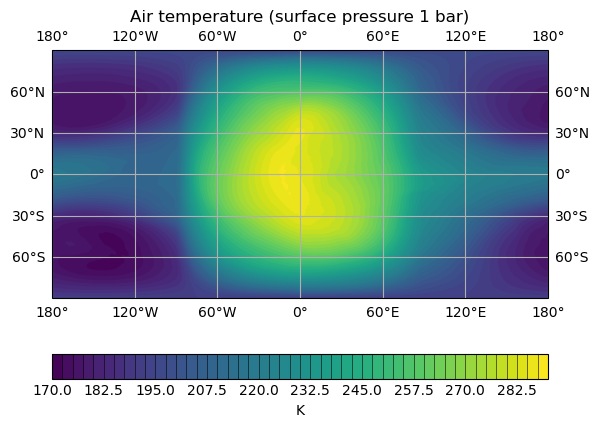

In [3]:
qplt.contourf(air_tempp[0], 50)

plt.gca().gridlines(draw_labels=True)
plt.title('Air temperature (surface pressure 1 bar)')
plt.show()

In [4]:
air_tempp_roll = aeolus.coord.roll_cube_pm180(air_tempp, add_shift=0)
air_tempp_roll[0].ndim
air_tempp_roll0 = air_tempp_roll[0]

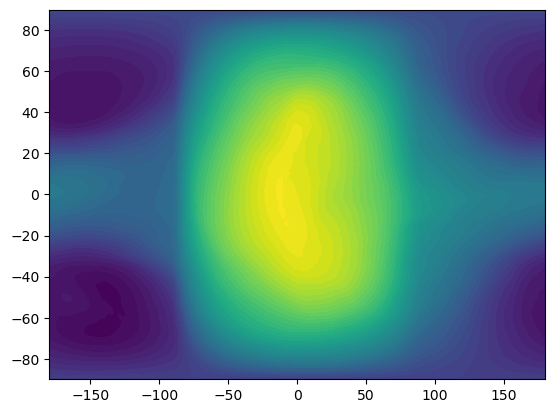

In [5]:
# contour = iplt.contour(air_tempp_roll[0])

x = air_tempp_roll0.coord('longitude').points
y = air_tempp_roll0.coord('latitude').points

data = air_tempp_roll0.data

X, Y = np.meshgrid(x, y)

plt.contourf(x, y, data, 50)

# plt.gca().gridlines(draw_labels=True)
plt.show()

In [6]:
dayside = air_tempp_roll.extract(iris.Constraint(longitude=lambda v:  (-75<= v <= 75)))
# dayside.ndim

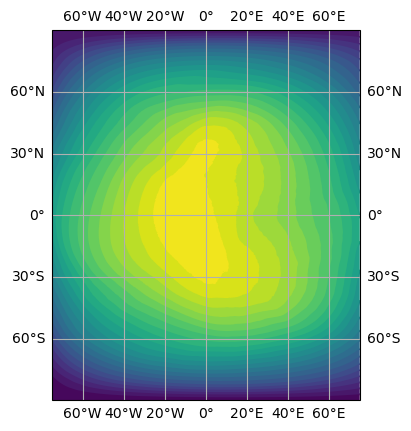

In [7]:
iplt.contourf(dayside[0], 25)

plt.gca().gridlines(draw_labels=True)
plt.show()

In [8]:
# dayside.coord('latitude').guess_bounds()
# dayside.coord('longitude').guess_bounds()
# grid_areas = iris.analysis.cartography.area_weights(dayside)

In [9]:
new_dayside = dayside.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)

/home/jj22956/.local/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(


In [10]:
print(new_dayside.coord('level_height').points)

[   20.00000351    53.33601107   100.00001346   160.00002974
   233.3360435    320.00005947   420.00006883   533.33607156
   660.00012574   800.00010766   953.33618141  1120.00018354
  1300.00019546  1493.33625818  1700.00033133  1920.00033222
  2153.33630188  2400.000364    2660.00043591  2933.33635352
  3220.00069177  3520.00071163  3833.33674128  4160.00098646
  4500.00070814  4853.33680881  5220.00067376  5600.00050748
  5993.33713042  6400.00110741  6820.0014634   7253.34517218
  7700.04084845  8160.13689865  8633.70593239  9120.90588588
  9621.96156182 10137.23436746 10667.25020984 11212.73805684
 11774.70582857 12354.50603323 12953.90550516 13575.16293716
 14221.14661473 14895.43369028 15602.45868417 16347.61152822
 17137.42749938 17979.73161855]


In [11]:
sample_points = [('level_height', np.linspace(400, 1250, 10))]
new_column = new_dayside.interpolate(sample_points, iris.analysis.Linear())

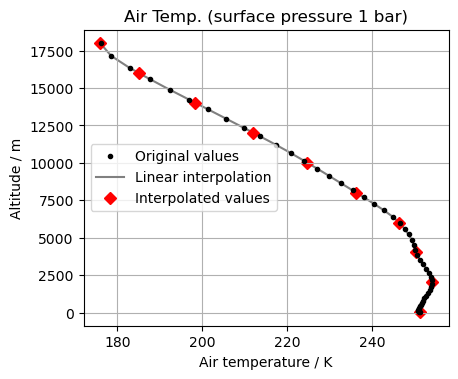

In [12]:
alt_coord = new_dayside.coord("level_height")

# Interpolate the "perfect" linear interpolation. Really this is just
# a high number of interpolation points, in this case 1000 of them.
altitude_points = [
    (
        "level_height",
        np.linspace(min(alt_coord.points), max(alt_coord.points), 1000),
    )
]
scheme = iris.analysis.Linear()
linear_column = new_dayside.interpolate(altitude_points, scheme)

# Now interpolate the data onto 10 evenly spaced altitude levels,
# as we did in the example.
altitude_points = [("level_height", np.linspace(20, 18000, 10))]
scheme = iris.analysis.Linear()
new_column = new_dayside.interpolate(altitude_points, scheme)

plt.figure(figsize=(5, 4), dpi=100)

# Plot the black markers for the original data.
qplt.plot(
    new_dayside,
    marker="o",
    color="black",
    linestyle="",
    markersize=3,
    label="Original values",
    zorder=2,
)

# Plot the gray line to display the linear interpolation.
qplt.plot(
    linear_column,
    color="gray",
    label="Linear interpolation",
    zorder=0,
)

# Plot the red markers for the new data.
qplt.plot(
    new_column,
    marker="D",
    color="red",
    linestyle="",
    label="Interpolated values",
    zorder=1,
)

ax = plt.gca()
# Space the plot such that the labels appear correctly.
plt.subplots_adjust(left=0.17, bottom=0.14)

# Limit the plot to a maximum of 5 ticks.
ax.xaxis.get_major_locator().set_params(nbins=5)

# Prevent matplotlib from using "offset" notation on the xaxis.
ax.xaxis.get_major_formatter().set_useOffset(False)

# Put some space between the line and the axes.
ax.margins(0.05)

# Place gridlines and a legend.
ax.grid()
plt.legend(loc="center left")
plt.title('Air Temp. (surface pressure 1 bar)')
plt.ylabel('Altitude / m')
plt.show()

In [13]:
# alt_coord2 = new_dayside.coord("level_height")

# alt_coord2 = alt_coord2()

In [14]:
strat_temps = pd.read_csv('/data/cluster4/jj22956/thunderstruck_files/stratosphere_temperature_array')
strat_alts = pd.read_csv('/data/cluster4/jj22956/thunderstruck_files/stratosphere_altitude_array')

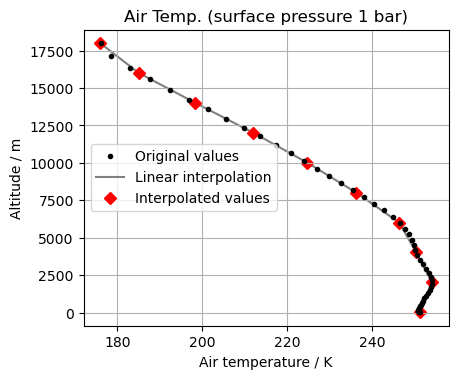

In [15]:


# Interpolate the "perfect" linear interpolation. Really this is just
# a high number of interpolation points, in this case 1000 of them.
altitude_points2 = [
    (
        "level_height",
        np.linspace(min(alt_coord.points), max(alt_coord.points), 1000),
    )
]
scheme = iris.analysis.Linear()
linear_column = new_dayside.interpolate(altitude_points, scheme)

# Now interpolate the data onto 10 evenly spaced altitude levels,
# as we did in the example.
altitude_points = [("level_height", np.linspace(20, 18000, 10))]
scheme = iris.analysis.Linear()
new_column = new_dayside.interpolate(altitude_points, scheme)

plt.figure(figsize=(5, 4), dpi=100)

# Plot the black markers for the original data.
qplt.plot(
    new_dayside,
    marker="o",
    color="black",
    linestyle="",
    markersize=3,
    label="Original values",
    zorder=2,
)

# Plot the gray line to display the linear interpolation.
qplt.plot(
    linear_column,
    color="gray",
    label="Linear interpolation",
    zorder=0,
)

# Plot the red markers for the new data.
qplt.plot(
    new_column,
    marker="D",
    color="red",
    linestyle="",
    label="Interpolated values",
    zorder=1,
)

ax = plt.gca()
# Space the plot such that the labels appear correctly.
plt.subplots_adjust(left=0.17, bottom=0.14)

# Limit the plot to a maximum of 5 ticks.
ax.xaxis.get_major_locator().set_params(nbins=5)

# Prevent matplotlib from using "offset" notation on the xaxis.
ax.xaxis.get_major_formatter().set_useOffset(False)

# Put some space between the line and the axes.
ax.margins(0.05)

# Place gridlines and a legend.
ax.grid()
plt.legend(loc="center left")
plt.title('Air Temp. (surface pressure 1 bar)')
plt.ylabel('Altitude / m')
plt.show()

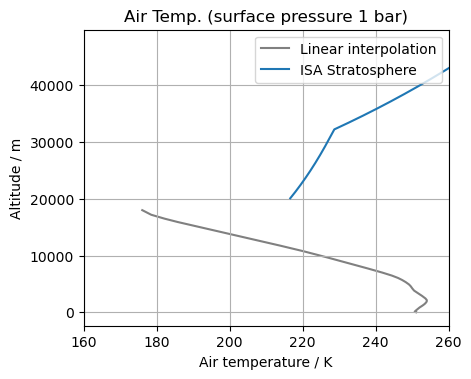

In [18]:
alt_coord = new_dayside.coord("level_height")

altitude_points = [
    (
        "level_height",
        np.linspace(min(alt_coord.points), max(alt_coord.points), 1000),
    )
]
scheme = iris.analysis.Linear()
linear_column = new_dayside.interpolate(altitude_points, scheme)

altitude_points = [("level_height", np.linspace(25, 24210, 10))]
scheme = iris.analysis.Linear()
new_column = new_dayside.interpolate(altitude_points, scheme)

plt.figure(figsize=(5, 4), dpi=100)

qplt.plot(
    linear_column,
    color="gray",
    label="Linear interpolation",
    zorder=0,
)

plt.plot(
    strat_temps, strat_alts,
    label= "ISA Stratosphere"
)

ax = plt.gca()
plt.subplots_adjust(left=0.17, bottom=0.14)

ax.xaxis.get_major_locator().set_params(nbins=5)

ax.xaxis.get_major_formatter().set_useOffset(False)

ax.margins(0.05)

ax.grid()
plt.legend(loc="upper right")
plt.title('Air Temp. (surface pressure 1 bar)')
plt.ylabel('Altitude / m')
plt.xlim(160, 260)
plt.show()